In [1]:
import pandas as pd

In [18]:
network1 = {
    'nodes': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J'],
    'edges': [
        ('A', 'B', 3), ('B', 'C', 2), ('C', 'D', 4), ('D', 'E', 1),
        ('E', 'F', 5), ('F', 'G', 2), ('G', 'H', 3), ('H', 'I', 4),
        ('I', 'J', 2), ('J', 'A', 3), ('B', 'E', 4),
        ('D', 'G', 2), ('E', 'H', 5), ('F', 'I', 1), ('G', 'J', 4)
    ]
}

network2 = {
    'nodes': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J'],
    'edges': [
        ('A', 'C', 5), ('C', 'E', 3), ('D', 'F', 4),
        ('E', 'G', 1), ('F', 'H', 3), ('G', 'I', 2), ('H', 'J', 5),
        ('A', 'E', 4), ('B', 'F', 3), ('C', 'G', 2), ('D', 'H', 1),
        ('E', 'I', 5), ('F', 'J', 4), ('A', 'J', 3), ('B', 'I', 2)
    ]
}

network3 = {
    'nodes': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J'],
    'edges': [
        ('A', 'D', 4), ('B', 'E', 3), ('D', 'G', 5),
        ('E', 'H', 1), ('F', 'I', 4), ('G', 'J', 3), ('A', 'H', 2),
        ('B', 'G', 5), ('C', 'J', 1), ('E', 'J', 4),
        ('F', 'H', 2), ('G', 'I', 5), ('H', 'J', 3), ('A', 'F', 4)
    ]
}

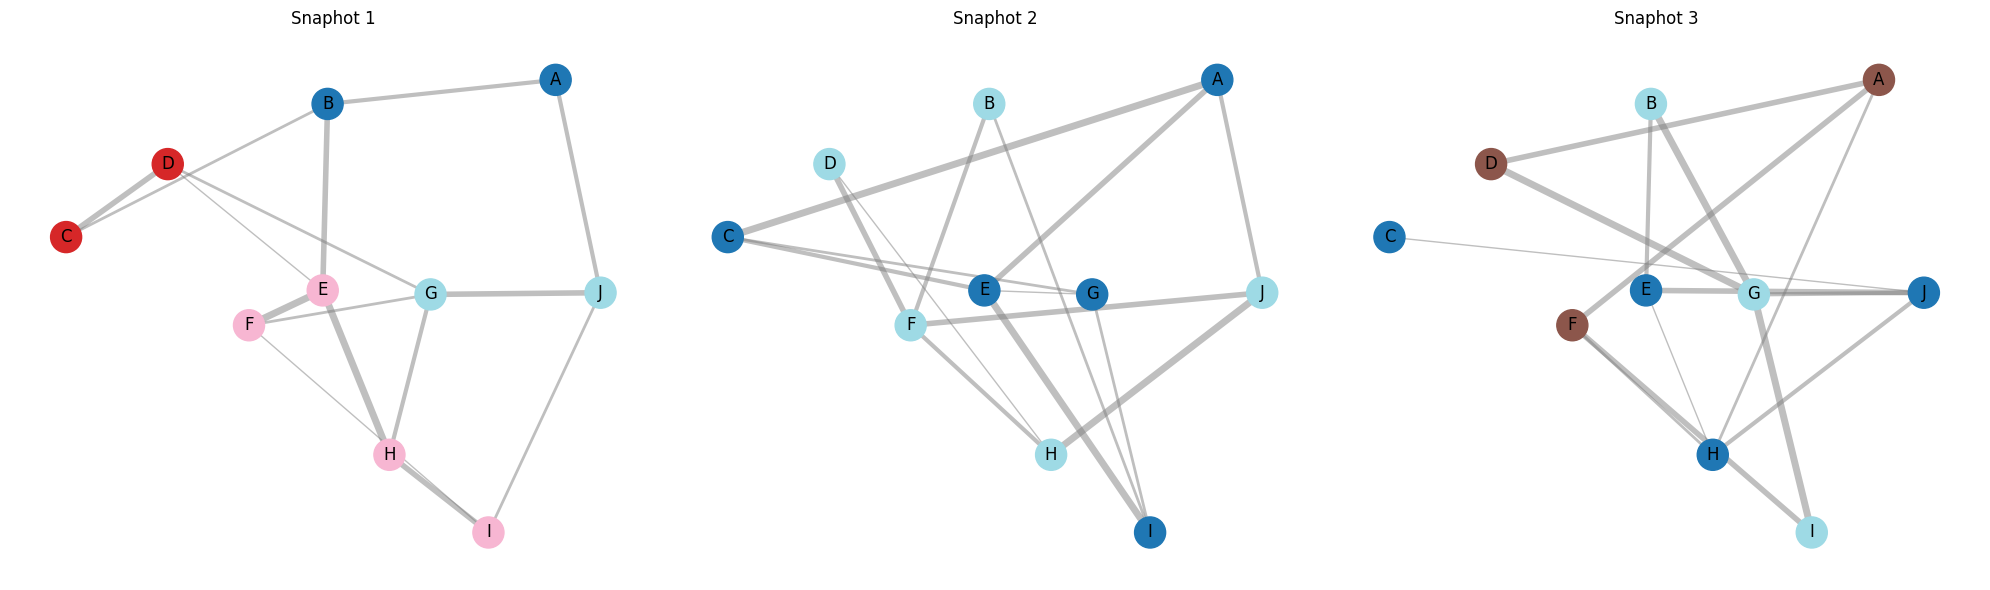

In [19]:
import networkx as nx
import matplotlib.pyplot as plt
from community import community_louvain
import numpy as np

def create_network(network_dict):
    G = nx.Graph()
    G.add_nodes_from(network_dict['nodes'])
    for edge in network_dict['edges']:
        G.add_edge(edge[0], edge[1], weight=edge[2])
    return G

def visualize_networks_fixed_positions(networks):
    # Create figure
    plt.figure(figsize=(20, 6))
    
    # Generate fixed positions using the first network
    G_first = create_network(networks[0])
    fixed_pos = nx.spring_layout(G_first, k=1, seed=42)
    
    # Visualize each network with fixed positions
    for i, network_dict in enumerate(networks, 1):
        # Create network
        G = create_network(network_dict)
        
        # Detect communities
        communities = community_louvain.best_partition(G)
        num_communities = len(set(communities.values()))
        
        # Create color map and assign colors
        colors = plt.cm.tab20(np.linspace(0, 1, num_communities))
        node_colors = [colors[communities[node]] for node in G.nodes()]
        
        # Get edge weights
        edge_weights = [G[u][v]['weight'] for u, v in G.edges()]
        
        # Create subplot
        plt.subplot(1, 3, i)
        plt.title(f'Snaphot {i}')
        plt.axis('off')
        
        # Draw network with fixed positions
        nx.draw_networkx_nodes(G, fixed_pos, node_color=node_colors, 
                             node_size=500)
        nx.draw_networkx_edges(G, fixed_pos, width=edge_weights,
                             edge_color='gray', alpha=0.5)
        nx.draw_networkx_labels(G, fixed_pos)

# Visualize all networks
networks = [network1, network2, network3]
visualize_networks_fixed_positions(networks)

# Adjust layout and display
plt.tight_layout()
plt.show()

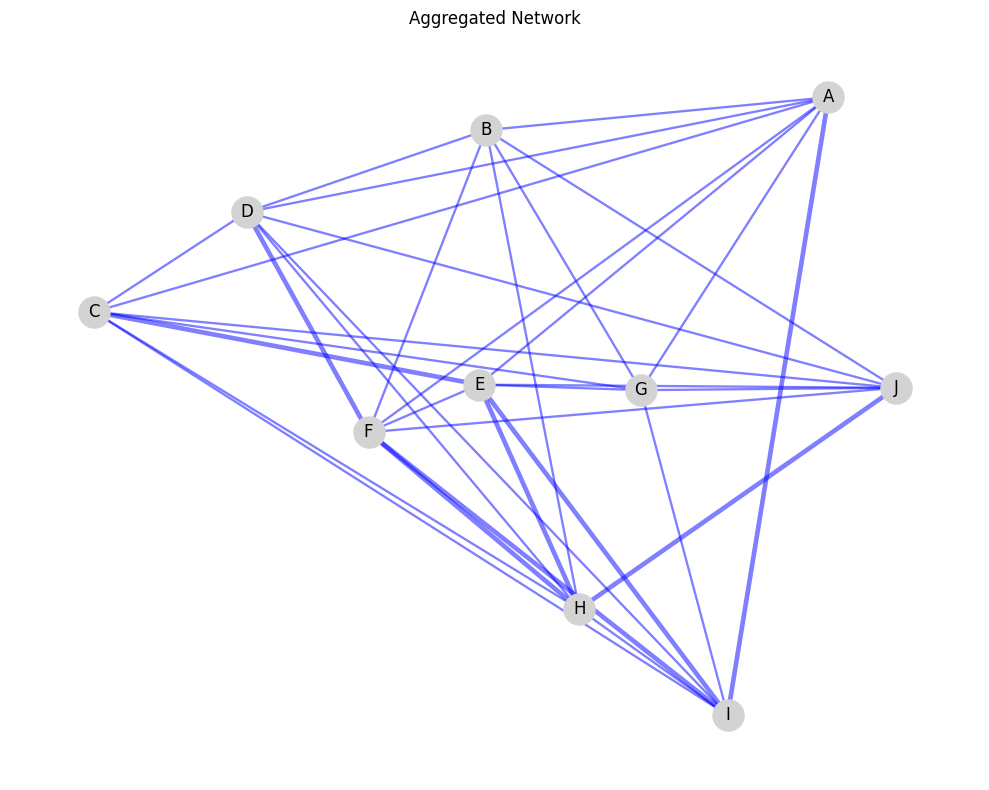

In [20]:
def create_aggregated_network(networks):
    """
    Creates an aggregated network where edge weights represent the proportion
    of times two nodes appear in the same community across all networks.
    """
    total_networks = len(networks)
    nodes = networks[0]['nodes']
    
    # Initialize co-occurrence matrix
    co_occurrence = {node1: {node2: 0 for node2 in nodes} for node1 in nodes}
    
    # Count how many times each pair of nodes appears in the same community
    for network_dict in networks:
        G = create_network(network_dict)
        communities = community_louvain.best_partition(G)
        
        for node1 in nodes:
            for node2 in nodes:
                if node1 < node2:
                    if communities[node1] == communities[node2]:
                        co_occurrence[node1][node2] += 1
                        co_occurrence[node2][node1] += 1
    
    # Create aggregated network with proportions as weights
    aggregated_network = {
        'nodes': nodes,
        'edges': []
    }
    
    for node1 in nodes:
        for node2 in nodes:
            if node1 < node2:
                proportion = co_occurrence[node1][node2] / total_networks
                if proportion > 0:
                    aggregated_network['edges'].append((node1, node2, proportion))
    
    return aggregated_network

def visualize_aggregated_network(networks):
    plt.figure(figsize=(10, 8))
    
    # Generate fixed positions using the first network
    G_first = create_network(networks[0])
    fixed_pos = nx.spring_layout(G_first, k=1, seed=42)
    
    # Create and visualize aggregated network
    aggregated = create_aggregated_network(networks)
    G_agg = create_network(aggregated)
    
    # Scale edge weights for visualization
    edge_weights = [5 * G_agg[u][v]['weight'] for u, v in G_agg.edges()]
    
    plt.title('Aggregated Network')
    plt.axis('off')
    
    nx.draw_networkx_nodes(G_agg, fixed_pos, node_color='lightgray', 
                          node_size=500)
    nx.draw_networkx_edges(G_agg, fixed_pos, width=edge_weights, 
                          edge_color='blue', alpha=0.5)
    nx.draw_networkx_labels(G_agg, fixed_pos)
    
    plt.tight_layout()
    plt.show()

# Run the visualization
networks = [network1, network2, network3]
visualize_aggregated_network(networks)